Epoch 1 completed


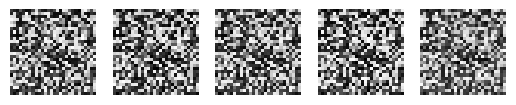

Epoch 2 completed
Epoch 3 completed


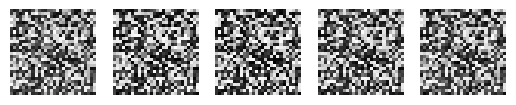

Epoch 4 completed
Epoch 5 completed


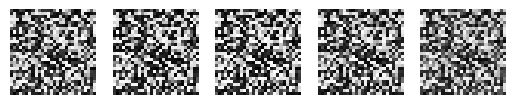

Epoch 6 completed
Epoch 7 completed


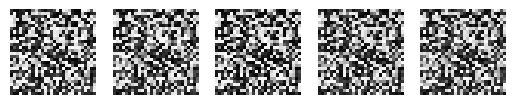

Epoch 8 completed
Epoch 9 completed


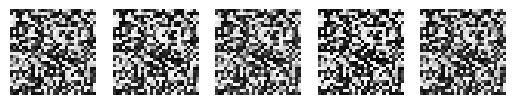

Epoch 10 completed


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

# 1. Load Dataset
(train_images, _), (_, _) = fashion_mnist.load_data()

# Normalize to [-1, 1]
train_images = (train_images - 127.5) / 127.5
train_images = train_images.reshape(-1, 28, 28, 1)

# 2. Build Generator
generator = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(100,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(28*28, activation='tanh'),
    layers.Reshape((28, 28, 1))
])

# 3. Build Discriminator
discriminator = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Combine GAN
discriminator.trainable = False

gan = models.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Training
epochs = 10
batch_size = 64

for epoch in range(epochs):
    for _ in range(train_images.shape[0] // batch_size):
        
        # Train Discriminator
        noise = np.random.normal(0, 1, (batch_size, 100))
        fake_images = generator.predict(noise, verbose=0)

        real_images = train_images[np.random.randint(0, train_images.shape[0], batch_size)]

        d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size, 1)))

        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, 100))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    print(f"Epoch {epoch+1} completed")

    # Show generated images
    if epoch % 2 == 0:
        noise = np.random.normal(0, 1, (5, 100))
        gen_images = generator.predict(noise, verbose=0)

        for i in range(5):
            plt.subplot(1, 5, i+1)
            plt.imshow(gen_images[i].reshape(28, 28), cmap='gray')
            plt.axis('off')
        plt.show()
